In [ ]:
import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F

In [ ]:
!pip install segmentation-models-pytorch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 26.4 MB/s eta 0:00:00


In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn.functional as F


class DoubleConv(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels, midChannels=None):
        super().__init__()
        
        midChannels = outputChannels if midChannels==None else midChannels

        self.conv1 = torch.nn.Conv2d(inputChannels, midChannels, 3, padding=1)
        self.batchNorm1 = torch.nn.BatchNorm2d(midChannels)
        self.relu1 = torch.nn.ReLU()
        self.conv2 = torch.nn.Conv2d(midChannels, outputChannels, 3, padding=1)
        self.batchNorm2 = torch.nn.BatchNorm2d(outputChannels)
        self.relu2 = torch.nn.ReLU()
    
    def forward(self, x):
        x = self.relu1(self.batchNorm1(self.conv1(x)))
        x = self.relu2(self.batchNorm2(self.conv2(x)))
        return x


class Down(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels):
        super().__init__()
        self.doubleConv = DoubleConv(inputChannels, outputChannels)
        self.maxPool = torch.nn.MaxPool2d((2,2))
        
    def forward(self,x):
        skip = self.doubleConv(x)
        down_sampled = F.max_pool2d(skip, (2,2))
        return skip, down_sampled


class Up(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels):
        super().__init__()

        self.decode = torch.nn.ConvTranspose2d(inputChannels-outputChannels, inputChannels-outputChannels, kernel_size=2, stride=2)
        self.doubleConv = DoubleConv(inputChannels, outputChannels)

    def crop(self, layer, target_size):
        _, _, layer_height, layer_width = layer.size()
        diff_y = (layer_height - target_size[0]) // 2
        diff_x = (layer_width - target_size[1]) // 2
        return layer[
            :, :, diff_y : (diff_y + target_size[0]), diff_x : (diff_x + target_size[1])
        ]

    def forward(self, down_sampled, skip_input):
        up_sampled = self.decode(down_sampled)
        cropped_skip = self.crop(skip_input, up_sampled.shape[2:])
        x = torch.cat((up_sampled, cropped_skip), dim=1)
        return self.doubleConv(x)


class UNet(torch.nn.Module):
    def __init__(self,inputChannels, outputChannels, midChannels=None):
        super().__init__()
    

        self.down1 = Down(inputChannels, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)
        
        self.doubleConv = DoubleConv(512, 1024)

        self.up1 = Up(512 + 1024, 512)
        self.up2 = Up(256 + 512, 256)
        self.up3 = Up(128 + 256, 128)
        self.up4 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, outputChannels, kernel_size=3, padding=1)


    def forward(self, x):
        skip1, x = self.down1(x)
        skip2, x = self.down2(x)
        skip3, x = self.down3(x)
        skip4, x = self.down4(x)

        x = self.doubleConv(x)

        x = self.up1(x, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, skip1)
        
        return self.lastConv(x)


base_model = UNet(1, 1).to(device)

In [ ]:
import torch
from torchvision import models

class UNet_VGG_4layer(torch.nn.Module):
    def __init__(self,input_channels, output_channels):
        super().__init__()

        # load the model
        self.vgg16 = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')
        self.vgg16.features[0] = torch.nn.Conv2d(input_channels, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        
        self.maxPool = torch.nn.MaxPool2d((2,2))

        self.doubleConv = DoubleConv(512, 1024)
        
        self.down1 = self.vgg16.features[:4] # 64 channel
        self.down2 = self.vgg16.features[5:9] # 128 channel
        self.down3 = self.vgg16.features[10:16] # 256 channel
        self.down4 = self.vgg16.features[17:23] # 512 channel

        self.up1 = Up(512 + 1024, 512)
        self.up2 = Up(256 + 512, 256)
        self.up3 = Up(128 + 256, 128)
        self.up4 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, output_channels, kernel_size=3, padding=1)

    def forward(self, x):

        skip1 = self.down1(x)
        x = self.maxPool(skip1)
        #print(f"skip1 {skip1.shape}, x {x.shape}")

        skip2 = self.down2(x)
        x = self.maxPool(skip2)
        #print(f"skip2 {skip2.shape}, x {x.shape}")

        skip3 = self.down3(x)
        x = self.maxPool(skip3)
        #print(f"skip3 {skip3.shape}, x {x.shape}")

        skip4 = self.down4(x)
        x = self.maxPool(skip4)
        #print(f"skip4 {skip4.shape}, x {x.shape}")


        x = self.doubleConv(x)

        x = self.up1(x, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, skip1)
        
        return self.lastConv(x)

model_4layer = UNet_VGG_4layer(1, 1).to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:06<00:00, 84.1MB/s]


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class UNet_5layer(torch.nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        # Load a pre-trained VGG16 model
        self.vgg16 = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')
        self.vgg16.features[0] = torch.nn.Conv2d(input_channels, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        
        self.relu = torch.nn.ReLU()
        
        self.maxPool = torch.nn.MaxPool2d((2,2))

        self.down1 = self.vgg16.features[:4] # 64 channel
        self.down2 = self.vgg16.features[5:9] # 128 channel
        self.down3 = self.vgg16.features[10:16] # 256 channel
        self.down4 = self.vgg16.features[17:23] # 512 channel
        self.down5 = nn.Sequential(*list(self.vgg16.features[24:30]), nn.Conv2d(512, 1024, kernel_size=3, padding=1))

        self.doubleConv = DoubleConv(1024, 1024)

        self.up1 = Up(1024 + 1024, 1024)
        self.up2 = Up(512 + 1024, 512)
        self.up3 = Up(256 + 512, 256)
        self.up4 = Up(128 + 256, 128)
        self.up5 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, output_channels, kernel_size=3, padding=1)

    def forward(self, x):

      skip1 = self.down1(x)
      x = self.maxPool(skip1)
      #print(f"skip1 {skip1.shape}, x {x.shape}")

      skip2 = self.down2(x)
      x = self.maxPool(skip2)
      #print(f"skip2 {skip2.shape}, x {x.shape}")

      skip3 = self.down3(x)
      x = self.maxPool(skip3)
      #print(f"skip3 {skip3.shape}, x {x.shape}")

      skip4 = self.down4(x)
      x = self.maxPool(skip4)
      #print(f"skip4 {skip4.shape}, x {x.shape}")

      skip5 = self.down5(x)
      x = self.maxPool(skip5)
      #print(f"skip5 {skip5.shape}, x {x.shape}")

      x = self.doubleConv(x)
      
      
      x = self.up1(x, skip5)
      x = self.up2(x, skip4)
      x = self.up3(x, skip3)
      x = self.up4(x, skip2)
      x = self.up5(x, skip1)
        
      return self.lastConv(x)

model_5layer = UNet_5layer(1, 1).to(device)

!unrar x drive/unet_data/data.rar

In [ ]:
torch.cuda.empty_cache()

<function torch.cuda.memory.empty_cache() -> None>

In [ ]:
# deneme

from pathlib import Path
import random

import torch.utils.data 
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from PIL import Image


class AstrocyteDataset(torch.utils.data.Dataset):

  def transform(self, image, mask):
      # Random horizontal flipping
      image = transforms.RandomHorizontalFlip(0.5)(image)
      mask = transforms.RandomHorizontalFlip(0.5)(mask)

      # Random vertical flipping
      image = transforms.RandomVerticalFlip(0.5)(image)
      mask = transforms.RandomVerticalFlip(0.5)(mask)
        
      # Random rotation
      image = transforms.RandomRotation(180)(image)
      mask = transforms.RandomRotation(180)(mask)

      # Transform to tensor
      image = TF.to_tensor(image)
      mask = TF.to_tensor(mask)

      return image, mask


  def __init__(self, train_dir, mask_dir, debug=False):
    self.train_img = {p.stem: p for p in train_dir.iterdir()}
    self.mask_img = {p.stem: p for p in mask_dir.iterdir()}

    self.ids = list(self.train_img.keys())

    self.debug = debug


  def __getitem__(self, index):
    # Get image id
    id_ = self.ids[index]
    # Load image
    image = Image.open(self.train_img[id_])
    mask = Image.open(self.mask_img[id_])

    if self.debug:
      orig_img = image.copy()
      orig_mask = mask.copy()

    image,mask = self.transform(image, mask)

    mask = mask / mask.max()

    # Return the image and the mask
    if self.debug:
      return image, mask, orig_img, orig_mask
    else:
      return image, mask

  def __len__(self):
    return len(self.ids)

dataset_debug_demo = AstrocyteDataset(train_dir = Path("/content/drive/MyDrive/Star/astrocyte_data/train"), mask_dir=Path("/content/drive/MyDrive/Star/astrocyte_data/train_label"), debug=True)

In [ ]:
from pathlib import Path
import random

import torch.utils.data 
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from PIL import Image


class AstrocyteDataset(torch.utils.data.Dataset):

  def transform(self, image, mask):
      # Random horizontal flipping
      if random.random() > 0.5:
          image = TF.hflip(image)
          mask = TF.hflip(mask)

      # Random vertical flipping
      if random.random() > 0.5:
          image = TF.vflip(image)
          mask = TF.vflip(mask)
        
      # Random rotation
      degrees = transforms.RandomRotation.get_params([-180, 180])
      image = TF.rotate(image, degrees)
      mask = TF.rotate(mask, degrees)

      # Transform to tensor
      image = TF.to_tensor(image)
      mask = TF.to_tensor(mask)

      return image, mask


  def __init__(self, train_dir, mask_dir, debug=False):
    self.train_img = {p.stem: p for p in train_dir.iterdir()}
    self.mask_img = {p.stem: p for p in mask_dir.iterdir()}

    self.ids = list(self.train_img.keys())

    self.debug = debug


  def __getitem__(self, index):
    # Get image id
    id_ = self.ids[index]
    # Load image
    image = Image.open(self.train_img[id_])
    mask = Image.open(self.mask_img[id_])

    if self.debug:
      orig_img = image.copy()
      orig_mask = mask.copy()

    image,mask = self.transform(image, mask)

    mask = mask / mask.max()

    # Return the image and the mask
    if self.debug:
      return image, mask, orig_img, orig_mask
    else:
      return image, mask

  def __len__(self):
    return len(self.ids)

dataset_astrocyte = AstrocyteDataset(train_dir = Path("/content/drive/MyDrive/Star/astrocyte_data/train"), mask_dir=Path("/content/drive/MyDrive/Star/astrocyte_data/train_label"))

In [ ]:
dataset_debug = AstrocyteDataset(train_dir = Path("/content/drive/MyDrive/Star/astrocyte_data/train"), mask_dir=Path("/content/drive/MyDrive/Star/astrocyte_data/train_label"), debug=True)

image, mask, orig_img, orig_mask = dataset_debug[0]
print(image.shape, mask.shape, len(dataset_debug), orig_img.size, orig_mask.size)

torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) 23 (256, 256) (256, 256)


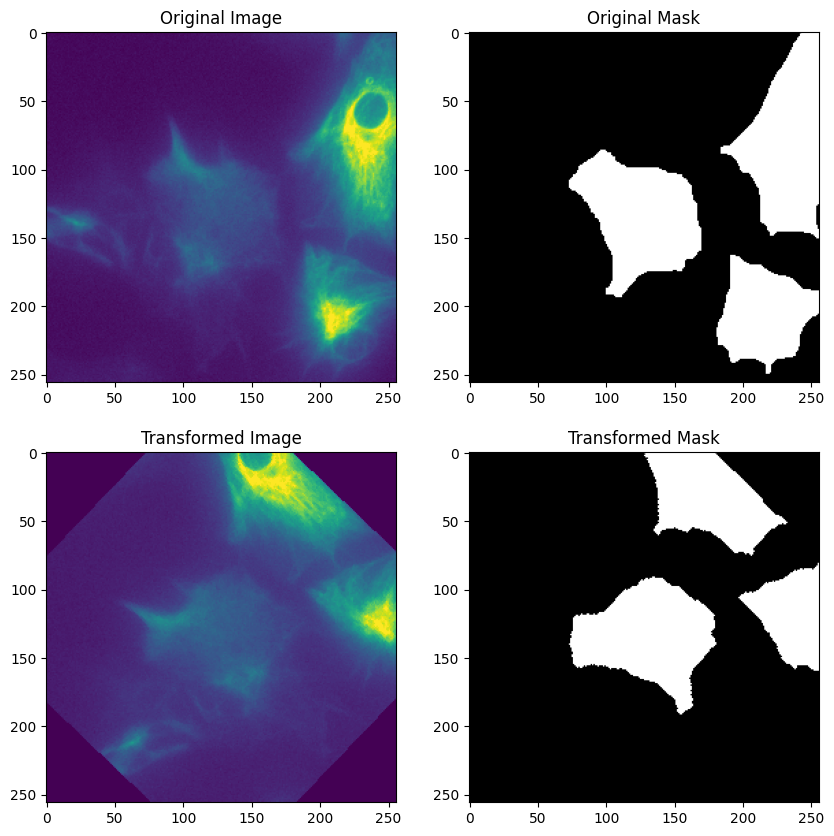

In [ ]:
def visualize_dataset(dataset, index):
    # Fetch the transformed and original images/masks
    image, mask, orig_image, orig_mask = dataset[index]

    # Convert tensors to numpy arrays for visualization
    image = image.numpy().transpose((1, 2, 0))
    mask = mask.numpy().transpose((1, 2, 0))

    fig, ax = plt.subplots(2, 2, figsize=(10, 10))

    # Show original image
    ax[0, 0].imshow(orig_image)
    ax[0, 0].set_title("Original Image")

    # Show original mask
    ax[0, 1].imshow(orig_mask, cmap='gray')
    ax[0, 1].set_title("Original Mask")

    # Show transformed image
    ax[1, 0].imshow(image)
    ax[1, 0].set_title("Transformed Image")

    # Show transformed mask
    ax[1, 1].imshow(mask, cmap='gray')
    ax[1, 1].set_title("Transformed Mask")

    plt.show()

# Usage
visualize_dataset(dataset_debug, 2)

In [ ]:
train = torch.utils.data.DataLoader(dataset_astrocyte, batch_size=1, shuffle=False)

valsize = int(len(train)*0.2)  # Reserve %20 for validation
trainsize = len(train) - valsize  # Reserve %80 for train

print(f"Validation size is :{valsize}, Training size is :{trainsize}")
trainset, valset = torch.utils.data.random_split(train, [trainsize, valsize])

Validation size is :4, Training size is :19


In [ ]:
from segmentation_models_pytorch.losses import FocalLoss, DiceLoss

optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = torch.nn.BCEWithLogitsLoss()

In [ ]:
def accuracy_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    correct = (y_pred == y_true).float().sum()
    total = y_true.numel()
    accuracy = correct / total
    return accuracy.item()

In [ ]:
def plot_loss_acc(loss_list, acc_list):
  plt.subplot(2,1,1)
  plt.plot([x for x in range(len(loss_list))], loss_list, "b-")
  plt.title("Loss over epochs")
  plt.annotate(f"{min(loss_list):.3f}", xy=(0.9, 0.9), xycoords='axes fraction', 
               horizontalalignment='right', verticalalignment='top')

  plt.subplot(2,1,2)
  plt.plot([x for x in range(len(acc_list))], acc_list, "b-")
  plt.title("Accuracy over epochs")
  plt.annotate(f"{max(acc_list):.3f}", xy=(0.9, 0.1), xycoords='axes fraction', 
               horizontalalignment='right', verticalalignment='top')

In [ ]:
from tqdm import tqdm


def training(model, loss_fn, optimizer, train_set, val_set, epoch):
    loss_list = []
    acc_list = []
    for epoch in range(epoch):
        model.train()
        epoch_loss = 0
        epoch_accuracy = 0
        for batch in trainset.dataset:
            Xs, ys = batch
            Xs = Xs.to(device)
            ys = ys.to(device)

            model.zero_grad()
            preds = model(Xs)
            loss = loss_fn(preds, ys)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            # Calculate accuracy
            with torch.no_grad():
                accuracy = accuracy_score(ys, preds)
                epoch_accuracy += accuracy
            
        average_loss = epoch_loss / len(trainset.dataset)
        average_accuracy = epoch_accuracy / len(trainset.dataset)
        print(f"Epoch {epoch+1} average loss: {average_loss:.3f}, average accuracy: {average_accuracy:.3f}", end=" ")

        # loss and accuracy on the validation set
        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for batch in val_set.dataset:
                Xs, ys = batch
                Xs = Xs.to(device)
                ys = ys.to(device)

                preds = model(Xs)
                loss = loss_fn(preds, ys)
                val_loss += loss.item()

                # Calculate accuracy
                val_accuracy += accuracy_score(ys, preds)
        
        val_average_loss = val_loss / len(val_set.dataset)
        val_average_accuracy = val_accuracy / len(val_set.dataset)
        print(f"average val loss: {val_average_loss:.3f}, average val accuracy: {val_average_accuracy:.3f}")
        loss_list.append(val_average_loss)
        acc_list.append(val_average_accuracy)

    return loss_list, acc_list
      

base_loss_list, base_acc_list= training(base_model, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)


Epoch 1 average loss: 0.277, average accuracy: 0.889 average val loss: 0.303, average val accuracy: 0.878
Epoch 2 average loss: 0.257, average accuracy: 0.892 average val loss: 0.284, average val accuracy: 0.882
Epoch 3 average loss: 0.246, average accuracy: 0.895 average val loss: 0.264, average val accuracy: 0.890
Epoch 4 average loss: 0.241, average accuracy: 0.899 average val loss: 0.239, average val accuracy: 0.894
Epoch 5 average loss: 0.247, average accuracy: 0.895 average val loss: 0.255, average val accuracy: 0.884
Epoch 6 average loss: 0.234, average accuracy: 0.901 average val loss: 0.221, average val accuracy: 0.907
Epoch 7 average loss: 0.224, average accuracy: 0.907 average val loss: 0.231, average val accuracy: 0.902
Epoch 8 average loss: 0.225, average accuracy: 0.906 average val loss: 0.236, average val accuracy: 0.903
Epoch 9 average loss: 0.233, average accuracy: 0.904 average val loss: 0.226, average val accuracy: 0.904
Epoch 10 average loss: 0.219, average accuracy

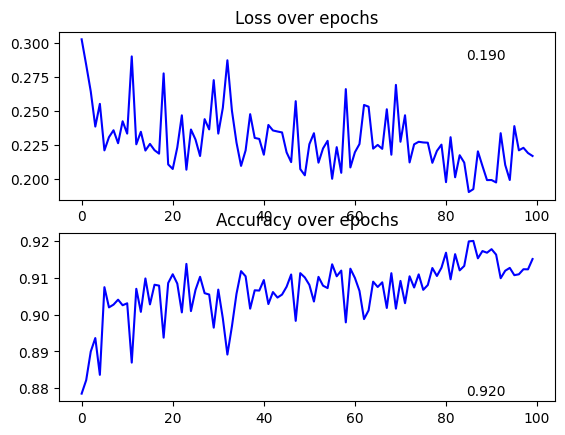

In [ ]:
plot_loss_acc(base_loss_list, base_acc_list)

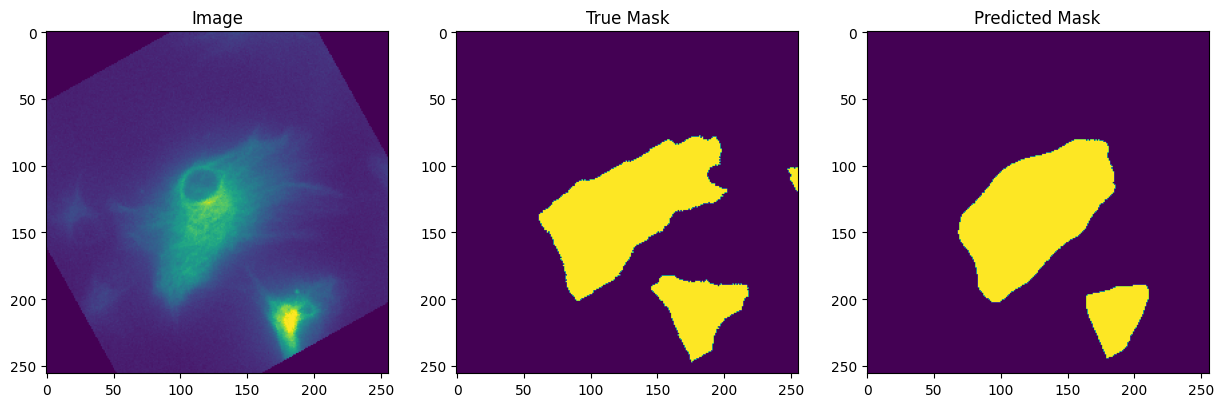

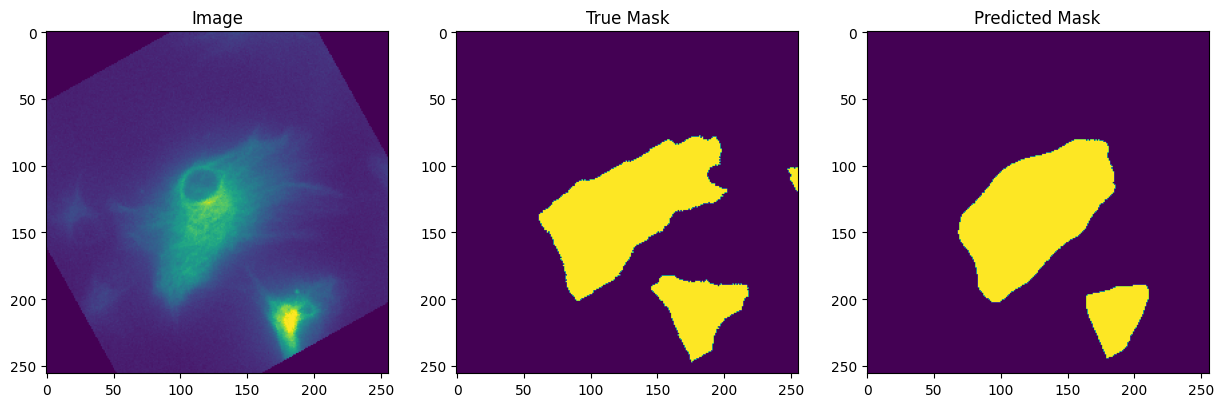

In [ ]:
def display_image_mask_prediction(model, image, mask, threshold=0.9):
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        model.eval()
        pred_mask = model(image_tensor).cpu()
        pred_mask = F.sigmoid(pred_mask)
        pred_mask = (pred_mask > threshold).float()

    image = image.cpu().permute(1, 2, 0).numpy()
    true_mask = mask.cpu().permute(1, 2, 0).numpy()
    pred_mask = pred_mask.squeeze(0).permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("True Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")

    plt.show()

for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(base_model, Xs[i-1], ys[i-1], threshold=0.6)
  break


In [ ]:
from segmentation_models_pytorch.losses import FocalLoss, DiceLoss

base_model = UNet(1, 1).to(device) # Called the model to reset weights

optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")


In [ ]:
dice_base_loss_list, dice_base_acc_list= training(base_model, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=300)

NameError: ignored

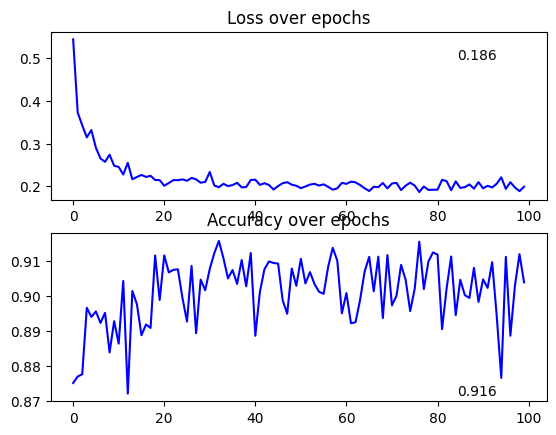

In [ ]:
plot_loss_acc(dice_base_loss_list, dice_base_acc_list)

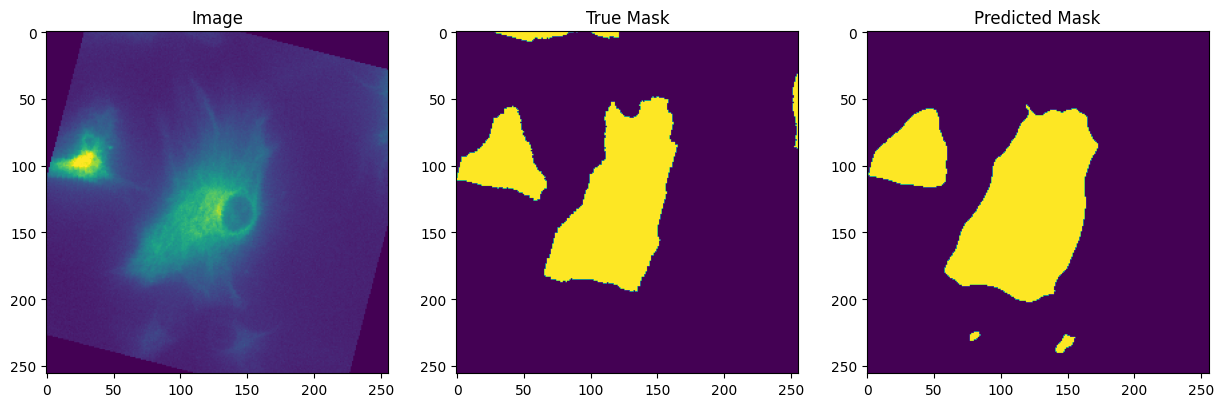

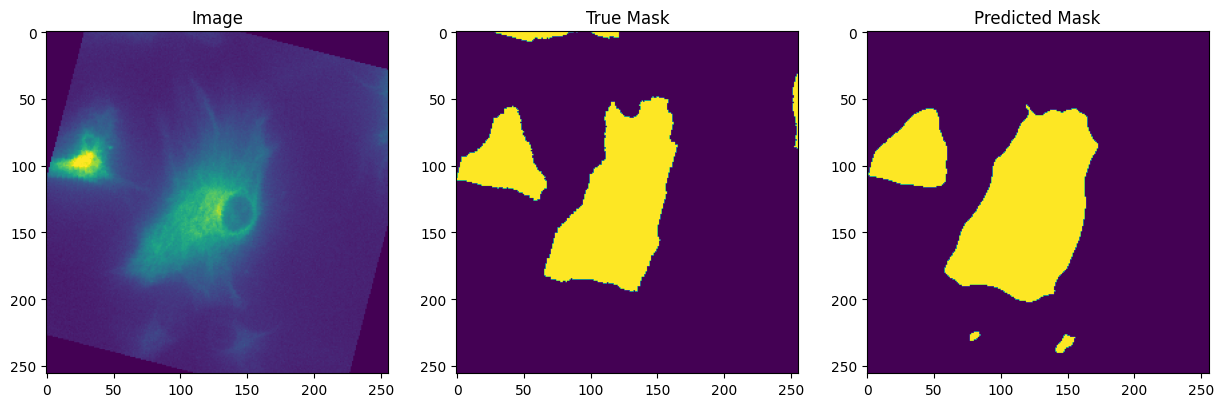

In [ ]:
for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(base_model, Xs[i-1], ys[i-1], threshold=0.6)
  break

In [ ]:
optimizer = torch.optim.Adam(model_4layer.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [ ]:
dice_4_loss_list, dice_4_acc_list= training(model_4layer, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.483, average accuracy: 0.863 average val loss: 0.558, average val accuracy: 0.879
Epoch 2 average loss: 0.381, average accuracy: 0.863 average val loss: 0.370, average val accuracy: 0.891
Epoch 3 average loss: 0.334, average accuracy: 0.884 average val loss: 0.330, average val accuracy: 0.885
Epoch 4 average loss: 0.298, average accuracy: 0.891 average val loss: 0.273, average val accuracy: 0.903
Epoch 5 average loss: 0.272, average accuracy: 0.899 average val loss: 0.333, average val accuracy: 0.883
Epoch 6 average loss: 0.255, average accuracy: 0.901 average val loss: 0.257, average val accuracy: 0.876
Epoch 7 average loss: 0.240, average accuracy: 0.905 average val loss: 0.252, average val accuracy: 0.903
Epoch 8 average loss: 0.246, average accuracy: 0.899 average val loss: 0.230, average val accuracy: 0.905
Epoch 9 average loss: 0.230, average accuracy: 0.906 average val loss: 0.262, average val accuracy: 0.859
Epoch 10 average loss: 0.221, average accuracy

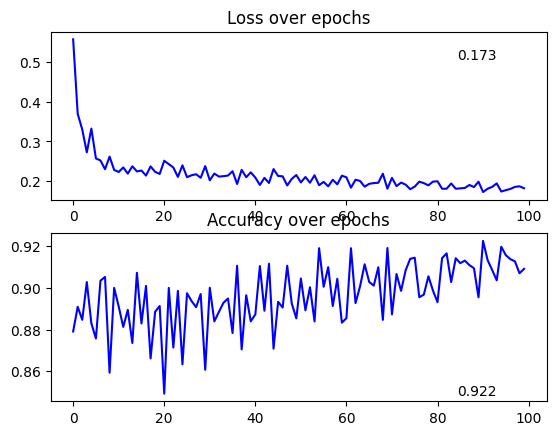

In [ ]:
plot_loss_acc(dice_4_loss_list, dice_4_acc_list)

In [ ]:
optimizer = torch.optim.Adam(model_5layer.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [ ]:
dice_5_loss_list, dice_5_acc_list= training(model_5layer, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=300)

Epoch 1 average loss: 0.127, average accuracy: 0.942 average val loss: 0.160, average val accuracy: 0.923
Epoch 2 average loss: 0.130, average accuracy: 0.941 average val loss: 0.162, average val accuracy: 0.923
Epoch 3 average loss: 0.129, average accuracy: 0.941 average val loss: 0.161, average val accuracy: 0.924
Epoch 4 average loss: 0.133, average accuracy: 0.939 average val loss: 0.163, average val accuracy: 0.923
Epoch 5 average loss: 0.128, average accuracy: 0.942 average val loss: 0.167, average val accuracy: 0.921
Epoch 6 average loss: 0.125, average accuracy: 0.944 average val loss: 0.164, average val accuracy: 0.922
Epoch 7 average loss: 0.125, average accuracy: 0.942 average val loss: 0.164, average val accuracy: 0.921
Epoch 8 average loss: 0.129, average accuracy: 0.942 average val loss: 0.164, average val accuracy: 0.920
Epoch 9 average loss: 0.129, average accuracy: 0.942 average val loss: 0.166, average val accuracy: 0.920
Epoch 10 average loss: 0.129, average accuracy

In [ ]:
plot_loss_acc(dice_5_loss_list, dice_5_acc_list)

NameError: ignored

In [ ]:
!pip install ternausnet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from ternausnet import models

ternaus = models.UNet16(num_classes=1, pretrained=True, is_deconv=True).to(device)
ternaus.conv1[0] = torch.nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
ternaus.to(device)
print(ternaus)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


UNet16(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15)

In [ ]:
optimizer = torch.optim.Adam(ternaus.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [ ]:
ternaus_loss_list, ternaus_acc_list= training(ternaus, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.644, average accuracy: 0.756 average val loss: 0.540, average val accuracy: 0.793
Epoch 2 average loss: 0.472, average accuracy: 0.827 average val loss: 0.269, average val accuracy: 0.848
Epoch 3 average loss: 0.267, average accuracy: 0.853 average val loss: 0.251, average val accuracy: 0.858
Epoch 4 average loss: 0.262, average accuracy: 0.858 average val loss: 0.251, average val accuracy: 0.871
Epoch 5 average loss: 0.263, average accuracy: 0.854 average val loss: 0.247, average val accuracy: 0.874
Epoch 6 average loss: 0.253, average accuracy: 0.864 average val loss: 0.248, average val accuracy: 0.871
Epoch 7 average loss: 0.246, average accuracy: 0.866 average val loss: 0.245, average val accuracy: 0.864
Epoch 8 average loss: 0.244, average accuracy: 0.870 average val loss: 0.243, average val accuracy: 0.866
Epoch 9 average loss: 0.245, average accuracy: 0.863 average val loss: 0.237, average val accuracy: 0.876
Epoch 10 average loss: 0.259, average accuracy

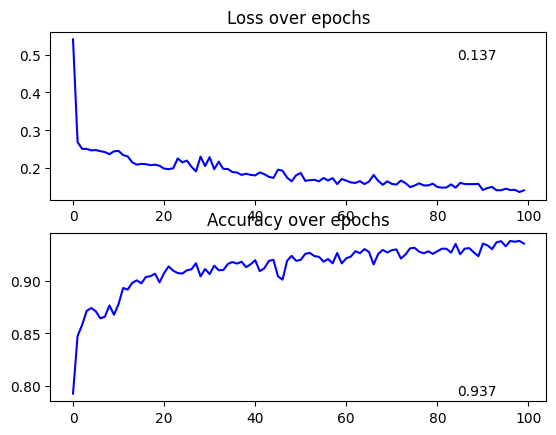

In [ ]:
plot_loss_acc(ternaus_loss_list, ternaus_acc_list)

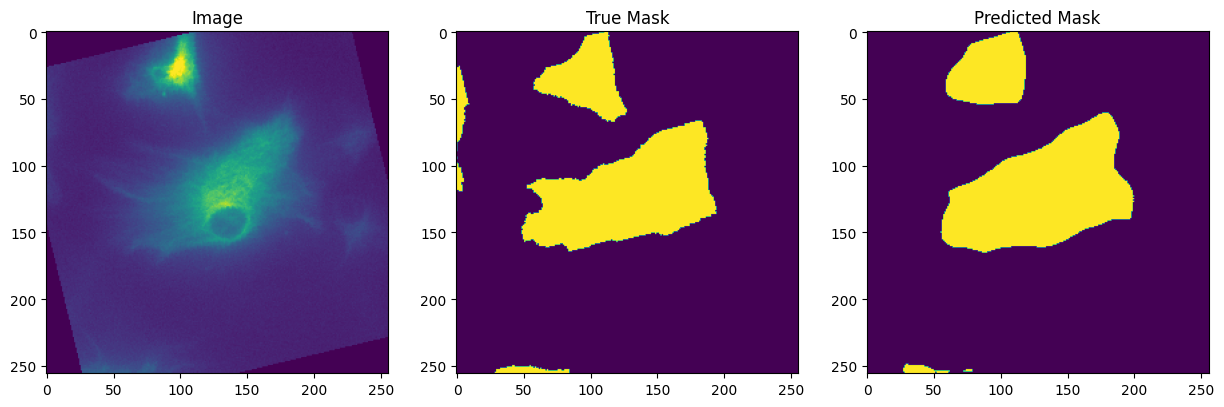

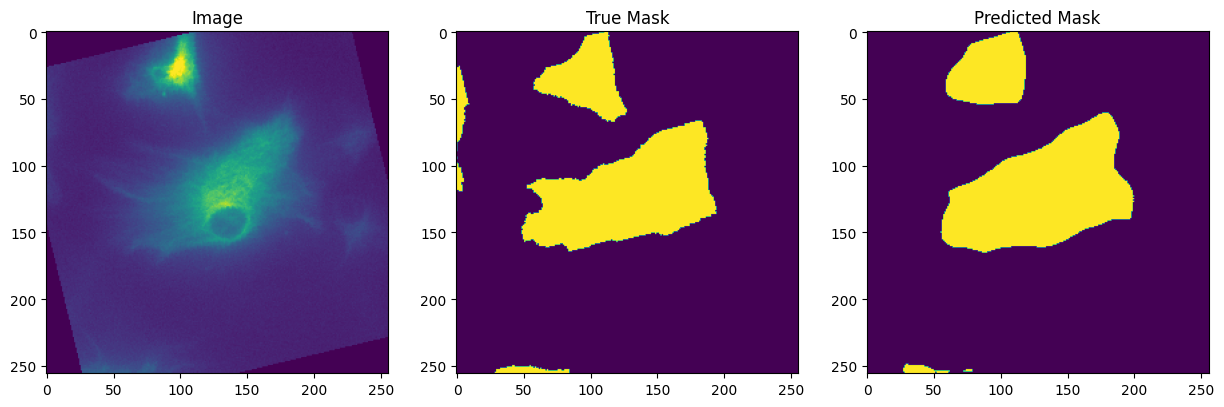

In [ ]:
for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(ternaus, Xs[i-1], ys[i-1], threshold=0.6)
  break